**Diana Itzel Soto Castañeda**

**Ciencia de Datos para Sensores Inteligentes**

# Imports

In [3]:
# system libraries
import os
import sys

print("Python:", sys.version)
print("Executable:", sys.executable)

Python: 3.10.19 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 16:41:31) [MSC v.1929 64 bit (AMD64)]
Executable: c:\Users\Diana\miniconda3\envs\pr_marcha\python.exe


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

# warnings
import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)


Configuración para visualización

In [5]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Practica 2 — Biométrico de marcha humana a partir de vídeo RGB-D

En esta práctica se analizan videos de marchas tomados a partir de una cámara RGB-D. A partir de la extracción de carácteristicas obtenidas al aplicar algoritmos de visión artificial. Se implementarán tres modelos con el próposito de clasificar los perfiles cinématicos de la marcha con los participantes.

## Descripción del conjunto de datos

El conjunto de datos está compuesto por secuencias de marcha capturadas mediante una cámara RGB-D (Intel RealSense) en un ambiente controlado. Para cada participante se registraron cuatro secuencias independientes, lo que permite analizar la variabilidad intra-sujeto.

Cada archivo se encuentra en formato .bag e incluye información de color (RGB) y profundidad (D). Las secuencias fueron etiquetadas mediante un archivo labels.csv, el cual contiene el identificador del sujeto, el número de repetición, el nombre del archivo y el timestamp de la grabación.

## Exploración inicial de las secuencias

La exploración inicial de las secuencias se realizó mediante scripts externos al notebook (disponibles en la carpeta src), permitiendo identificar inconsistencias en la continuidad de algunos videos RGB. Asimismo, se observó que los datos de profundidad presentan una mayor pérdida de información en comparación con las secuencias RGB.

Por esta razón, la información de profundidad se empleará únicamente como complemento para la validación espacial de los keypoints y para la extracción de métricas específicas que requieran información tridimensional, evitando su uso como fuente principal de características. Estas observaciones se tomaron en cuenta durante la curaduría del conjunto de datos, con el objetivo de garantizar la calidad y consistencia de la información utilizada en el entrenamiento de los modelos.

Durante la exploración inicial se identificaron secuencias RGB que presentan problemas significativos de continuidad en los frames. Se tomó la decisión de excluir dichas secuencias, lo que reduce el número de repeticiones válidas disponibles para algunos participantes. Aunque esta decisión sacrifica datos para el entrenamiento de los modelos, también evita introducir ruido innecesario.


### Selección de keypoints y normalización con MediaPipe

Para el análisis de la marcha se seleccionó un subconjunto de keypoints corporales proporcionados por MediaPipe Pose. En particular, se consideraron los keypoints correspondientes a las extremidades inferiores (caderas, rodillas y tobillos) como base del análisis, ya que permiten caracterizar el movimiento cíclico de la marcha y el comportamiento articular.


In [6]:
# KEYPOINTS = {
#     "hip_l": 23,
#     "knee_l": 25,
#     "ankle_l": 27,
#     "hip_r": 24,
#     "knee_r": 26,
#     "ankle_r": 28,
#     "shoulder_l": 11,
#     "shoulder_r": 12,
#}

Durante la extracción de pose se aplicó una normalización geométrica básica, consistente en centrar las coordenadas de los keypoints con respecto al centro de la pelvis en cada frame. Esta normalización permite eliminar el efecto de la traslación global del sujeto dentro del campo de visión, manteniendo la información relativa del movimiento corporal. No se aplicaron normalizaciones estadísticas globales en esta etapa, las cuales se reservan para el análisis y entrenamiento de modelos.


## Extracción de keypoints

Antes de realizar la extracción de la pose se realizó una verificación visual de los keypoints de MediaPipe superpuestos sobre las secuencias RGB, se observó que la detección de pose mediante MediaPipe es altamente dependiente de la escala del sujeto en la imagen. En particular, en varios videos la detección resulta consistente únicamente en el último **tercio de la secuencia**, cuando el sujeto se encuentra más cercano a la cámara y el torso ocupa un mayor número de píxeles en la imagen. En las fases iniciales de la marcha, donde el sujeto se encuentra más alejado, la detección de pose es intermitente o inexistente, a pesar de que el movimiento de las extremidades inferiores es visible.

Esta limitación está asociada a las características propias del modelo de pose 2D, el cual requiere información clara del torso para activar una detección robusta de la pose completa. Como consecuencia, la cantidad de frames útiles para el análisis de la marcha se ve reducida si se emplean las secuencias originales sin ningún tipo de ajuste espacial.

Con el objetivo de incrementar la cantidad de frames válidos y obtener una representación más completa del patrón de marcha, se decidió implementar un recorte adaptativo de la imagen RGB, se intentó utilizar la información de profundidad la cual resulto insuficiente, así que se evalúo el uso de YOLOv8 para la detección de la persona. Esta verificación permitió confirmar la presencia del sujeto desde los primeros frames de cada secuencia, evidenciando que la restricción en la detección temprana proviene del modelo de pose de MediaPipe y no de la ausencia de información visual. En consecuencia, se decidió incorporar YOLOv8 como etapa previa de detección para definir una región de interés (ROI), sobre la cual se aplica posteriormente la estimación de pose, permitiendo una detección más temprana y estable a lo largo de la marcha.

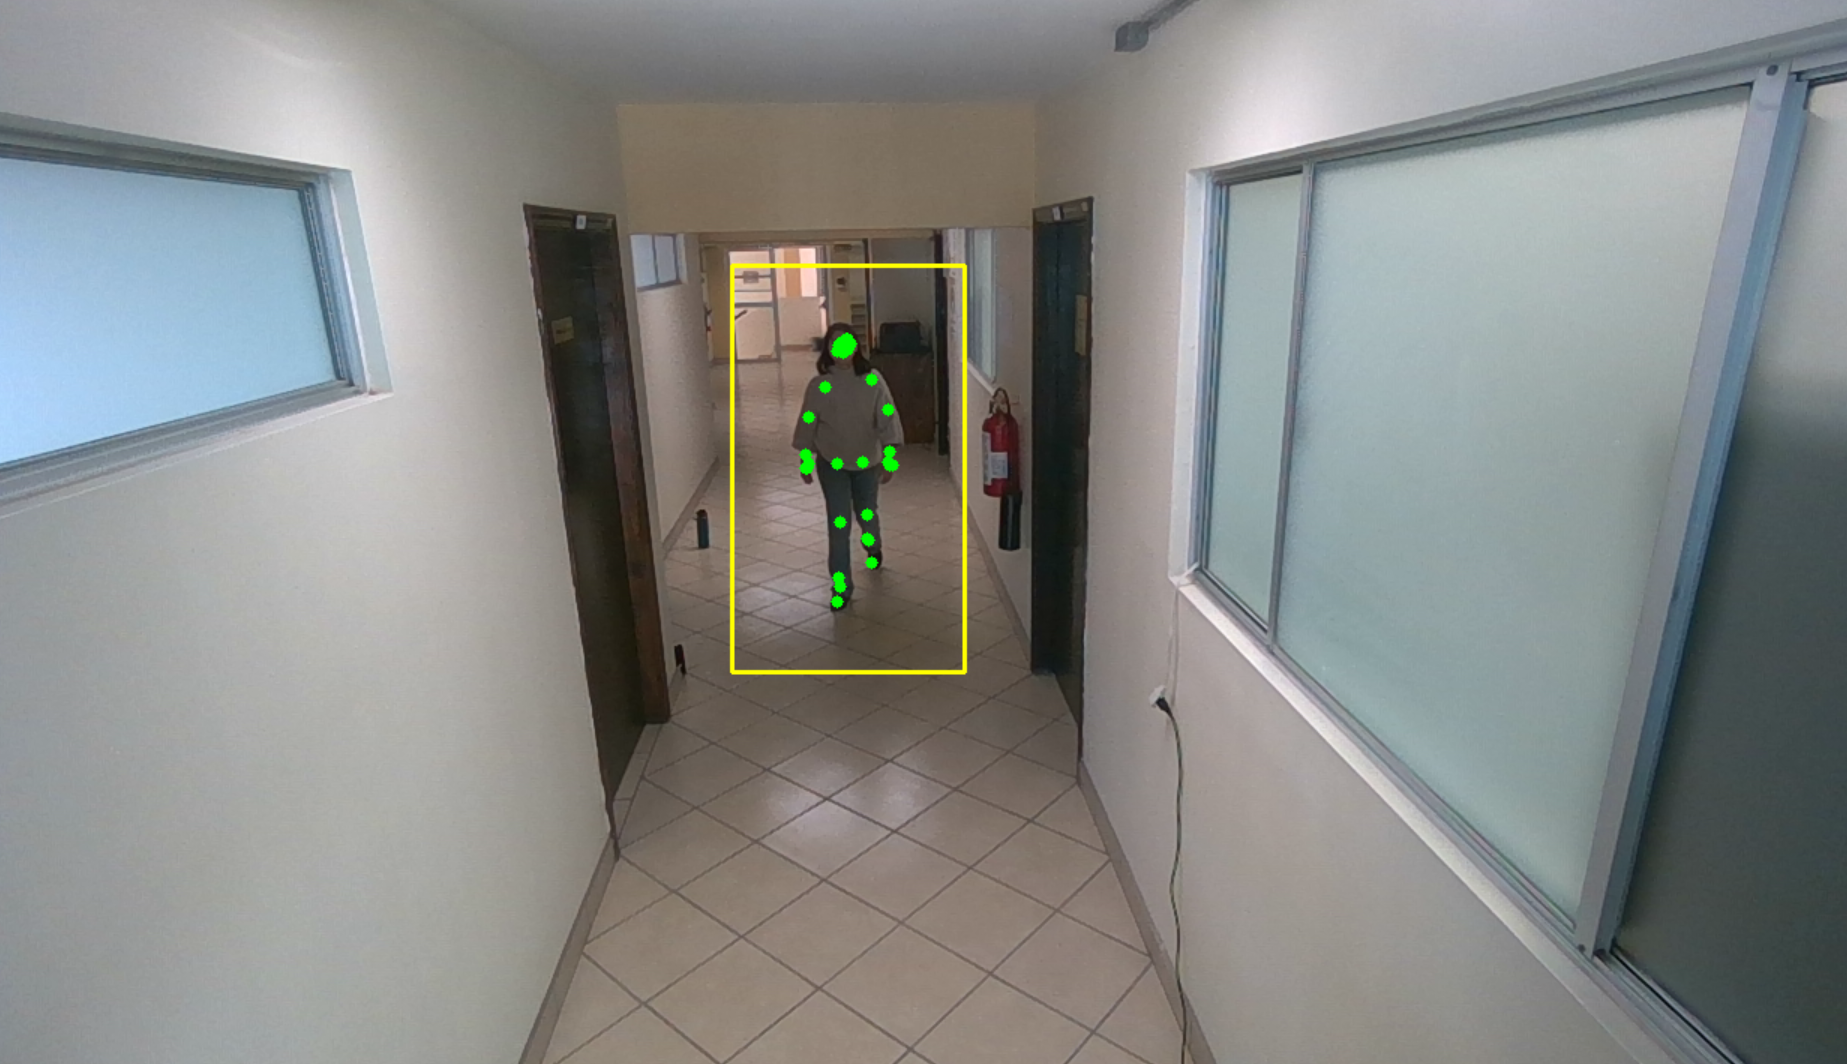
Captura de imagen al reproducir replay_pose_yolo_roi.py. En la imagen se observa la región de interés (ROI) (recuadro amarillo) y algunos keypoints (MediaPipe) de la figura. Demostrando que ahora es posible detectar la posé desde inicios de la grabación. La creación del ROI también sirve para la eliminación de ruido.

Se extrajerón los *Keypoints* implementando todas las consideraciones antes descritas. La extracción se llevo a cabó fuera del entorno de Jupyter, empleando el script src\extract_pose_roi.py. Los Keypoints se normalizaron con respecto a la cadera y se alamcenarón en un archivo (data\pose_features_roi.csv)

### Curaduría

Dado que la extracción de pose y la normalización espacial se realizaron previamente mediante scripts externos, el análisis posterior se desarrolló sobre los archivos CSV generados. Esta separación permite trabajar en Jupyter con representaciones compactas y reproducibles de las secuencias, facilitando la curaduría temporal y la extracción de características sin depender del procesamiento directo de los archivos de video.

### Carga de Datos de los Keypoints en archivo CSV

In [7]:
# =========================
# Rutas
# =========================
PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"

CSV_PATH = DATA_DIR / "pose_features.csv"
#CSV_TEST_EV = DATA_DIR / "validacion_externa" / "pose_features_test.csv"

# =========================
# Cargar datos
# =========================
df = pd.read_csv(CSV_PATH)

print("Dimensiones del dataset:", df.shape)
df.head()

## Carga de archivos de validación externa

#df_test = pd.read_csv(CSV_TEST_EV)

Dimensiones del dataset: (3590, 27)


,subject,trial,frame,hip_l_x,hip_l_y,hip_l_z,knee_l_x,knee_l_y,knee_l_z,ankle_l_x,...,knee_r_z,ankle_r_x,ankle_r_y,ankle_r_z,shoulder_l_x,shoulder_l_y,shoulder_l_z,shoulder_r_x,shoulder_r_y,shoulder_r_z
0,Diana_Itzel,1,197,0.014731,0.000827,0.194,0.015172,0.076573,0.348,0.016206,...,0.132,-0.006412,0.218705,-0.027,0.032215,-0.128137,0.087,-0.022856,-0.127773,0.005
1,Diana_Itzel,1,198,0.015091,-0.001360,0.073,0.013688,0.074581,0.339,0.014573,...,0.131,-0.007604,0.215448,0.036,0.029629,-0.131074,0.000,-0.026193,-0.126882,0.009
2,Diana_Itzel,1,199,0.015061,-0.002359,0.141,0.012860,0.083183,0.474,0.013806,...,0.132,-0.006995,0.215184,0.040,0.028000,-0.138862,0.094,-0.027990,-0.132012,0.040
3,Diana_Itzel,1,200,0.015121,-0.002988,0.156,0.012343,0.084140,0.462,0.013290,...,0.115,-0.005922,0.211922,0.065,0.026615,-0.142266,0.092,-0.030300,-0.133762,-0.008
4,Diana_Itzel,1,201,0.015088,-0.002832,0.125,0.012089,0.087046,0.404,0.013260,...,0.129,-0.005185,0.208847,0.081,0.025848,-0.143596,0.072,-0.031659,-0.135126,0.017


### Inspección de los datos

In [8]:
df.info()
df.describe().T
df.isna().mean().sort_values(ascending=False).head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3590 entries, 0 to 3589
Data columns (total 27 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   subject       3590 non-null   object 
 1   trial         3590 non-null   int64  
 2   frame         3590 non-null   int64  
 3   hip_l_x       3590 non-null   float64
 4   hip_l_y       3590 non-null   float64
 5   hip_l_z       2844 non-null   float64
 6   knee_l_x      3590 non-null   float64
 7   knee_l_y      3590 non-null   float64
 8   knee_l_z      2273 non-null   float64
 9   ankle_l_x     3590 non-null   float64
 10  ankle_l_y     3590 non-null   float64
 11  ankle_l_z     1935 non-null   float64
 12  hip_r_x       3590 non-null   float64
 13  hip_r_y       3590 non-null   float64
 14  hip_r_z       2864 non-null   float64
 15  knee_r_x      3590 non-null   float64
 16  knee_r_y      3590 non-null   float64
 17  knee_r_z      2239 non-null   float64
 18  ankle_r_x     3590 non-null 

ankle_r_z       0.490529
ankle_l_z       0.461003
knee_r_z        0.376323
knee_l_z        0.366852
hip_l_z         0.207799
shoulder_r_z    0.202507
hip_r_z         0.202228
shoulder_l_z    0.201950
trial           0.000000
frame           0.000000
dtype: float64

Se observa una pérdida parcial de información en la componente de profundidad (Z) de algunos keypoints, particularmente en rodillas y tobillos. Sin embargo, los keypoints en los ejes X e Y se encuentran completos. Se toma la decisión de usar (X) y (Y) para los feature principales mientras que la información en Z se utilizará de forma selectiva.

## Extracción de características

### Ángulos de rodilla

In [9]:
angles_l = []
angles_r = []

for _, row in df.iterrows():
    hip_l = np.array([row["hip_l_x"], row["hip_l_y"]])
    knee_l = np.array([row["knee_l_x"], row["knee_l_y"]])
    ankle_l = np.array([row["ankle_l_x"], row["ankle_l_y"]])

    hip_r = np.array([row["hip_r_x"], row["hip_r_y"]])
    knee_r = np.array([row["knee_r_x"], row["knee_r_y"]])
    ankle_r = np.array([row["ankle_r_x"], row["ankle_r_y"]])

    # Vectores
    ba_l = hip_l - knee_l
    bc_l = ankle_l - knee_l

    ba_r = hip_r - knee_r
    bc_r = ankle_r - knee_r

    # Ángulo izquierda
    cos_l = np.dot(ba_l, bc_l) / (np.linalg.norm(ba_l) * np.linalg.norm(bc_l))
    cos_l = np.clip(cos_l, -1.0, 1.0)
    angle_l = np.degrees(np.arccos(cos_l))

    # Ángulo derecha
    cos_r = np.dot(ba_r, bc_r) / (np.linalg.norm(ba_r) * np.linalg.norm(bc_r))
    cos_r = np.clip(cos_r, -1.0, 1.0)
    angle_r = np.degrees(np.arccos(cos_r))

    angles_l.append(angle_l)
    angles_r.append(angle_r)

df["knee_angle_l"] = angles_l
df["knee_angle_r"] = angles_r

df[["knee_angle_l", "knee_angle_r"]].head()


,knee_angle_l,knee_angle_r
0,179.303629,174.873141
1,178.053069,175.709332
2,177.143016,176.757639
3,176.587250,177.592116
4,176.195270,177.934419


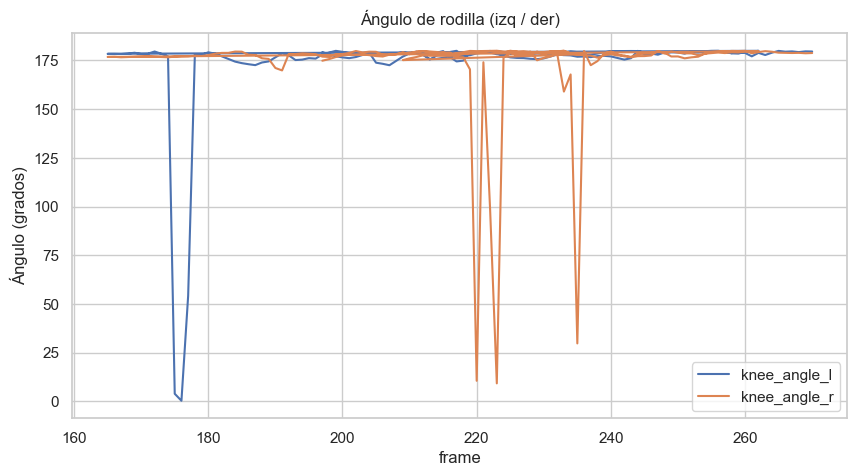

In [10]:
df[df["subject"] == df["subject"].iloc[0]].plot(
    x="frame",
    y=["knee_angle_l", "knee_angle_r"],
    title="Ángulo de rodilla (izq / der)"
)
plt.ylabel("Ángulo (grados)")
plt.show()

Se identificaron discontinuidades abruptas asociadas a detecciones erróneas de los keypoints en frames aislados. Dado que dichas variaciones no corresponden a movimientos fisiológicamente plausibles, se aplicó un filtrado temporal ligero e interpolación local para eliminar artefactos sin alterar la dinámica global de la marcha.

In [11]:


# 1. Eliminar valores no fisiológicos
df.loc[df["knee_angle_l"] < 90, "knee_angle_l"] = np.nan
df.loc[df["knee_angle_r"] < 90, "knee_angle_r"] = np.nan

# 2. Interpolación temporal por secuencia
df["knee_angle_l"] = (
    df.groupby(["subject", "trial"])["knee_angle_l"]
      .transform(lambda x: x.interpolate(limit=5))
)

df["knee_angle_r"] = (
    df.groupby(["subject", "trial"])["knee_angle_r"]
      .transform(lambda x: x.interpolate(limit=5))
)

df[["knee_angle_l", "knee_angle_r"]].head()


,knee_angle_l,knee_angle_r
0,179.303629,174.873141
1,178.053069,175.709332
2,177.143016,176.757639
3,176.587250,177.592116
4,176.195270,177.934419


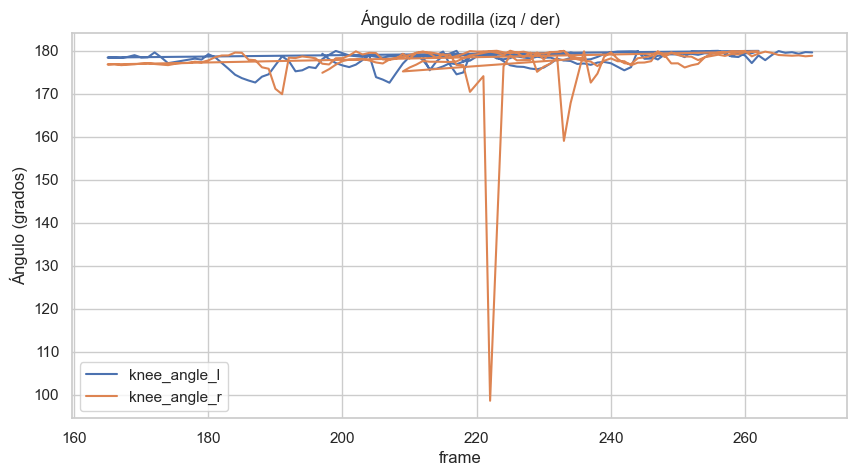

In [12]:
df[df["subject"] == df["subject"].iloc[0]].plot(
    x="frame",
    y=["knee_angle_l", "knee_angle_r"],
    title="Ángulo de rodilla (izq / der)"
)
plt.ylabel("Ángulo (grados)")
plt.show()

Tras la interpolación temporal, la señal angular de rodilla presenta una continuidad adecuada y valores coherentes, permitiendo la extracción de características de alto nivel sin introducir artefactos significativos.

#### Segmentación de ciclos de marcha 

Se emplea el ángulo de rodilla para segmentar los ciclos de marcha.

Un ciclo = De un mínimo al siguiente mínimo.

Para ello primero se limpia la señal y se detectan los picos:

In [13]:
# Asegurar que los angulos de rodilla existan antes de segmentar ciclos
if "knee_angle_r" not in df.columns or "knee_angle_l" not in df.columns:
    angles_l = []
    angles_r = []

    for _, row in df.iterrows():
        hip_l = np.array([row["hip_l_x"], row["hip_l_y"]])
        knee_l = np.array([row["knee_l_x"], row["knee_l_y"]])
        ankle_l = np.array([row["ankle_l_x"], row["ankle_l_y"]])

        hip_r = np.array([row["hip_r_x"], row["hip_r_y"]])
        knee_r = np.array([row["knee_r_x"], row["knee_r_y"]])
        ankle_r = np.array([row["ankle_r_x"], row["ankle_r_y"]])

        ba_l = hip_l - knee_l
        bc_l = ankle_l - knee_l
        ba_r = hip_r - knee_r
        bc_r = ankle_r - knee_r

        cos_l = np.dot(ba_l, bc_l) / (np.linalg.norm(ba_l) * np.linalg.norm(bc_l))
        cos_l = np.clip(cos_l, -1.0, 1.0)
        angle_l = np.degrees(np.arccos(cos_l))

        cos_r = np.dot(ba_r, bc_r) / (np.linalg.norm(ba_r) * np.linalg.norm(bc_r))
        cos_r = np.clip(cos_r, -1.0, 1.0)
        angle_r = np.degrees(np.arccos(cos_r))

        angles_l.append(angle_l)
        angles_r.append(angle_r)

    df["knee_angle_l"] = angles_l
    df["knee_angle_r"] = angles_r


#Suavizado de la señal
def savgol_filter(x, window_length=11, polyorder=2):
    x = np.asarray(x, dtype=float)
    if x.size < 3:
        return x.copy()
    if window_length % 2 == 0:
        window_length += 1
    window_length = min(window_length, x.size if x.size % 2 == 1 else x.size - 1)
    window_length = max(window_length, 3)
    pad = window_length // 2
    x_pad = np.pad(x, (pad, pad), mode="reflect")
    kernel = np.ones(window_length, dtype=float) / window_length
    return np.convolve(x_pad, kernel, mode="valid")

# Los picos son los puntos de máxima flexión de rodilla
def find_peaks(x, distance=1, prominence=0):
    x = np.asarray(x, dtype=float)
    if x.size < 3:
        return np.array([], dtype=int), {}
    # Maximos locales (tolerante a mesetas)
    left = x[:-2]
    mid = x[1:-1]
    right = x[2:]
    is_peak = (mid >= left) & (mid >= right) & ((mid > left) | (mid > right))
    candidates = np.where(is_peak)[0] + 1
    # Ignorar 'prominence' para mantener deteccion permisiva
    # Enforce distance (greedy por altura)
    if distance > 1 and len(candidates) > 1:
        order = candidates[np.argsort(x[candidates])[::-1]]
        selected = []
        for idx in order:
            if all(abs(idx - s) >= distance for s in selected):
                selected.append(idx)
        candidates = np.array(sorted(selected), dtype=int)
    return candidates, {}

# Almacenar picos por secuencia
all_peaks_r = []
all_peaks_l = []

# Procesar cada sujeto-trial por separado
for (subject, trial), group in df.groupby(["subject", "trial"]):
    # Obtener indices globales del grupo
    indices = group.index.values

    # Rodilla derecha
    signal_r = group["knee_angle_r"].values

    # Verificar que hay suficientes datos y no contiene NaNs
    if len(signal_r) > 11 and not np.any(np.isnan(signal_r)):
        signal_smooth_r = savgol_filter(signal_r, window_length=11, polyorder=2)

        peaks_r, _ = find_peaks(
            -signal_smooth_r,
            #Se probarón distancias y prominencias distintas, sin embargo un criterio extricto de distancia y prominencia no se ajustaba a la variabilidad de los datos, por lo que se optó por un criterio más permisivo.
            distance=20,      # ~0.67s entre pasos
            prominence=10     # Permite detectar variaciones sutiles.
        )

        valid_peaks_r = [
            p for p in peaks_r
            if signal_smooth_r[p] < 145
        ]

        # Convertir indices locales a globales
        global_peaks_r = indices[valid_peaks_r]
        all_peaks_r.extend(global_peaks_r)

    # Rodilla izquierda
    signal_l = group["knee_angle_l"].values

    # Verificar que hay suficientes datos y no contiene NaNs
    if len(signal_l) > 11 and not np.any(np.isnan(signal_l)):
        signal_smooth_l = savgol_filter(signal_l, window_length=11, polyorder=2)

        peaks_l, _ = find_peaks(
            -signal_smooth_l,
            distance=15,      # Reducido
            prominence=10     # Ignorado en el helper
        )

        valid_peaks_l = [
            p for p in peaks_l
            if signal_smooth_l[p] < 145  # Relajado
        ]

        global_peaks_l = indices[valid_peaks_l]
        all_peaks_l.extend(global_peaks_l)

peaks_r = np.array(sorted(all_peaks_r))
peaks_l = np.array(sorted(all_peaks_l))

print(f"Picos derecha: {len(peaks_r)}")
print(f"Picos izquierda: {len(peaks_l)}")
print(f"Secuencias procesadas: {df.groupby(['subject', 'trial']).ngroups}")

Picos derecha: 5
Picos izquierda: 0
Secuencias procesadas: 48


La detección de picos refleja problemas con la rodilla izquierda.

##### Visualización

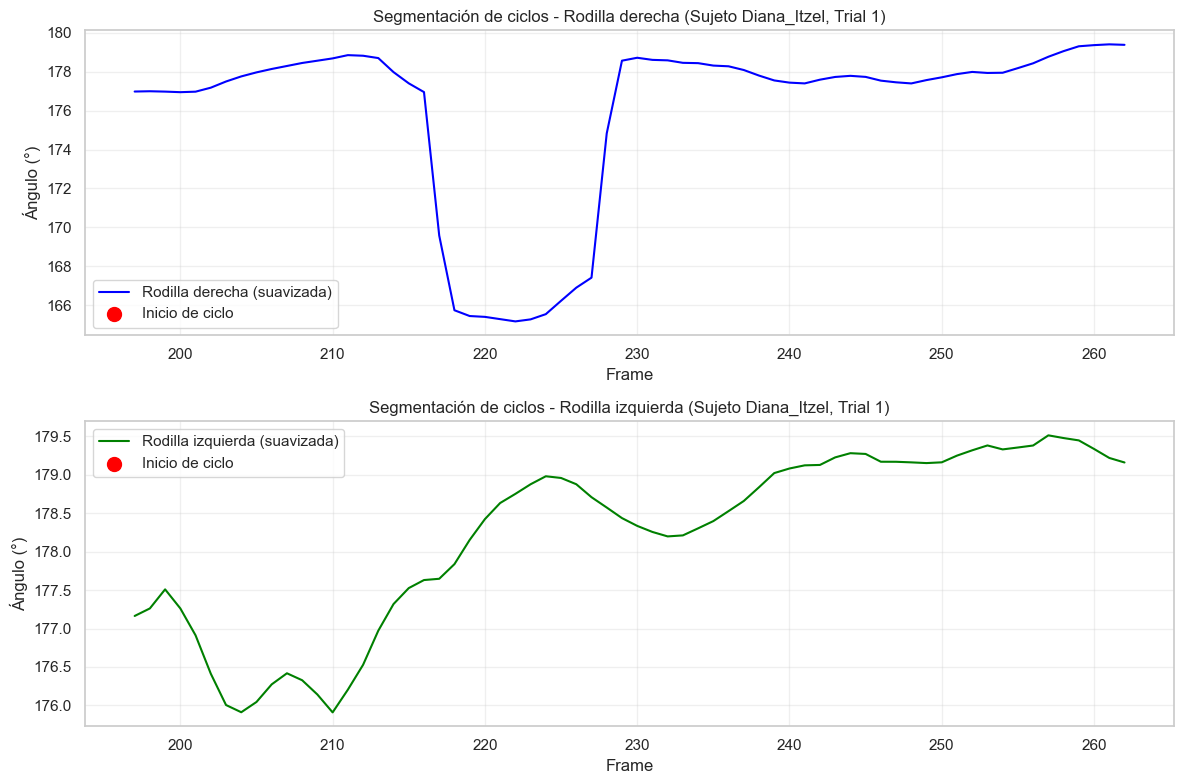


 Ciclos detectados en esta secuencia:
   Rodilla derecha: 0
   Rodilla izquierda: 0


In [14]:
def plot_cycle_segmentation(subject, trial):
    """
    Visualiza la segmentación de ciclos para un sujeto y trial específico.
    Si los datos contienen NaNs, busca automáticamente la primera secuencia válida.
    
    Parámetros:
    -----------
    subject : str
        Nombre del sujeto
    trial : int
        Número de trial
    """
    # Filtrar datos de la secuencia
    sample_data = df[(df["subject"] == subject) & (df["trial"] == trial)]
    
    if sample_data.empty:
        print(f"No existe la secuencia: Sujeto {subject}, Trial {trial}")
        return
    
    sample_indices = sample_data.index.values
    signal_r = sample_data["knee_angle_r"].values
    signal_l = sample_data["knee_angle_l"].values
    frames = sample_data["frame"].values
    
    # Verificar validez de datos
    has_valid_data = (
        not np.any(np.isnan(signal_r)) and 
        not np.any(np.isnan(signal_l)) and 
        len(signal_r) > 11
    )
    
    # Si datos inválidos, buscar una secuencia válida
    if not has_valid_data:
        print(f"La secuencia {subject}, Trial {trial} contiene valores NaN.")
        print("Buscando una secuencia válida...")
        
        for (subj, tr), group in df.groupby(["subject", "trial"]):
            sig_r = group["knee_angle_r"].values
            sig_l = group["knee_angle_l"].values
            
            if (not np.any(np.isnan(sig_r)) and 
                not np.any(np.isnan(sig_l)) and 
                len(sig_r) > 11):
                
                subject = subj
                trial = tr
                sample_data = group
                sample_indices = group.index.values
                signal_r = sig_r
                signal_l = sig_l
                frames = group["frame"].values
                print(f"✓ Visualizando: {subject}, Trial {trial}")
                break
        else:
            print("No hay ninguna secuencia válida en el dataset")
            return
    
    # Suavizar señales
    signal_smooth_r = savgol_filter(signal_r, window_length=11, polyorder=2)
    signal_smooth_l = savgol_filter(signal_l, window_length=11, polyorder=2)
    
    # Obtener picos para esta secuencia
    peaks_r_sample = peaks_r[np.isin(peaks_r, sample_indices)]
    peaks_l_sample = peaks_l[np.isin(peaks_l, sample_indices)]
    
    # Convertir a índices locales
    peaks_r_local = np.searchsorted(sample_indices, peaks_r_sample)
    peaks_l_local = np.searchsorted(sample_indices, peaks_l_sample)
    
    # Visualizar
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    
    # Rodilla derecha
    ax1.plot(frames, signal_smooth_r, label="Rodilla derecha (suavizada)", color="blue")
    ax1.scatter(frames[peaks_r_local], signal_smooth_r[peaks_r_local],
               color="red", s=100, label="Inicio de ciclo", zorder=5)
    ax1.set_xlabel("Frame")
    ax1.set_ylabel("Ángulo (°)")
    ax1.set_title(f"Segmentación de ciclos - Rodilla derecha (Sujeto {subject}, Trial {trial})")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Rodilla izquierda
    ax2.plot(frames, signal_smooth_l, label="Rodilla izquierda (suavizada)", color="green")
    ax2.scatter(frames[peaks_l_local], signal_smooth_l[peaks_l_local],
               color="red", s=100, label="Inicio de ciclo", zorder=5)
    ax2.set_xlabel("Frame")
    ax2.set_ylabel("Ángulo (°)")
    ax2.set_title(f"Segmentación de ciclos - Rodilla izquierda (Sujeto {subject}, Trial {trial})")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n Ciclos detectados en esta secuencia:")
    print(f"   Rodilla derecha: {len(peaks_r_sample)}")
    print(f"   Rodilla izquierda: {len(peaks_l_sample)}")

# Visualizar una secuencia de ejemplo
plot_cycle_segmentation("Diana_Itzel", 1)


La visualización refleja que no se ha cubierto una buena detección de ciclos de marcha para la rodilla izquierda. Para algunas secuencias tampoco se detectan ciclos en la rodilla derecha

Definición de ciclos

In [15]:
# Convertir picos a ciclos (rangos entre picos consecutivos)
def create_cycles(peaks, df):
    """
    Convierte un array de picos en una lista de ciclos (start_idx, end_idx),
    validando que ambos picos pertenezcan a la misma secuencia (sujeto+trial).
    """
    cycles = []
    for i in range(len(peaks) - 1):
        start_idx = peaks[i]
        end_idx = peaks[i + 1]
        
        # Verificar que ambos picos pertenecen a la misma secuencia
        if (df.iloc[start_idx]["subject"] == df.iloc[end_idx]["subject"] and
            df.iloc[start_idx]["trial"] == df.iloc[end_idx]["trial"]):
            cycles.append((start_idx, end_idx))
    
    return cycles

# Generar ciclos para ambas rodillas
cycles_r = create_cycles(peaks_r, df)
cycles_l = create_cycles(peaks_l, df)

print(f"✓ Ciclos válidos rodilla derecha: {len(cycles_r)}")
print(f"✓ Ciclos válidos rodilla izquierda: {len(cycles_l)}")
print(f"  (Los ciclos que cruzan límites de secuencia fueron descartados)")


✓ Ciclos válidos rodilla derecha: 0
✓ Ciclos válidos rodilla izquierda: 0
  (Los ciclos que cruzan límites de secuencia fueron descartados)


#### Diagnóstico de detección de ciclos

Se agregó esta celdad de diagnóstico de detección de ciclos


In [16]:
# Diagnóstico detallado
print("=" * 80)
print("DIAGNÓSTICO DE DETECCIÓN DE CICLOS")
print("=" * 80)

print(f"\nPICOS DETECTADOS:")
print(f"   Picos rodilla derecha: {len(peaks_r)}")
print(f"   Picos rodilla izquierda: {len(peaks_l)}")

if len(peaks_r) > 0:
    print(f"\n   Primeros 5 índices de picos derechos: {peaks_r[:5]}")
if len(peaks_l) > 0:
    print(f"   Primeros 5 índices de picos izquierdos: {peaks_l[:5]}")

print(f"\nCICLOS DEFINIDOS:")
print(f"   Ciclos rodilla derecha: {len(cycles_r)}")
print(f"   Ciclos rodilla izquierda: {len(cycles_l)}")

# Analizar secuencias
print(f"\nANÁLISIS DE SECUENCIAS:")
n_sequences = df.groupby(["subject", "trial"]).ngroups
print(f"   Total de secuencias: {n_sequences}")

# Ver cuántas secuencias tienen suficientes datos
valid_sequences = 0
for (subject, trial), group in df.groupby(["subject", "trial"]):
    signal_r = group["knee_angle_r"].values
    signal_l = group["knee_angle_l"].values
    
    has_enough_r = len(signal_r) > 11 and not np.any(np.isnan(signal_r))
    has_enough_l = len(signal_l) > 11 and not np.any(np.isnan(signal_l))
    
    if has_enough_r or has_enough_l:
        valid_sequences += 1

print(f"   Secuencias con datos suficientes: {valid_sequences}")

# Verificar una secuencia al azar
print(f"\nEJEMPLO DE SECUENCIA:")
for (subject, trial), group in df.groupby(["subject", "trial"]):
    signal_r = group["knee_angle_r"].values
    
    if len(signal_r) > 11 and not np.any(np.isnan(signal_r)):
        print(f"   Sujeto: {subject}, Trial: {trial}")
        print(f"   Frames: {len(signal_r)}")
        print(f"   Rango de ángulos: [{signal_r.min():.1f}°, {signal_r.max():.1f}°]")
        
        # Aplicar el mismo procesamiento que en la detección
        signal_smooth = savgol_filter(signal_r, window_length=11, polyorder=2)
        peaks_test, properties = find_peaks(
            -signal_smooth,
            distance=20,
            prominence=10
        )
        
        valid_peaks_test = [p for p in peaks_test if signal_smooth[p] < 145]
        
        print(f"   Picos detectados (antes de filtro de ángulo): {len(peaks_test)}")
        print(f"   Picos válidos (< 145°): {len(valid_peaks_test)}")
        
        if len(peaks_test) > 0:
            angles_at_peaks = signal_smooth[peaks_test]
            print(f"   Ángulos en los picos: min={angles_at_peaks.min():.1f}°, max={angles_at_peaks.max():.1f}°")
        
        break  # Solo mostrar la primera secuencia válida

if len(peaks_r) == 0 and len(peaks_l) == 0:
    print("No se detectaron picos en ninguna rodilla.")

elif len(cycles_r) == 0 and len(cycles_l) == 0:
    print(" Se detectaron picos pero no se formaron ciclos.")
    print("   Los picos consecutivos no pertenecen a la misma secuencia")
    print("   Se requiere al menos 2 picos en la misma secuencia para formar un ciclo")


DIAGNÓSTICO DE DETECCIÓN DE CICLOS

PICOS DETECTADOS:
   Picos rodilla derecha: 5
   Picos rodilla izquierda: 0

   Primeros 5 índices de picos derechos: [ 308 2073 2190 2621 2702]

CICLOS DEFINIDOS:
   Ciclos rodilla derecha: 0
   Ciclos rodilla izquierda: 0

ANÁLISIS DE SECUENCIAS:
   Total de secuencias: 48
   Secuencias con datos suficientes: 45

EJEMPLO DE SECUENCIA:
   Sujeto: Diana_Itzel, Trial: 1
   Frames: 66
   Rango de ángulos: [98.6°, 180.0°]
   Picos detectados (antes de filtro de ángulo): 3
   Picos válidos (< 145°): 0
   Ángulos en los picos: min=165.2°, max=177.4°
 Se detectaron picos pero no se formaron ciclos.
   Los picos consecutivos no pertenecen a la misma secuencia
   Se requiere al menos 2 picos en la misma secuencia para formar un ciclo


Dado que hay muy pocos ciclos detectados, probé relajar los parámetros permisivos y quitar el filtro de ángulo. Como la grabación es de frente, considero que la precisión del cálculo del ángulo articular a partir de landmarks 2D con MediaPipe se ve limitada. Sin embargo, al relajar los parámetros me encontre con una cantidad de ciclos absurda (195) -imposible dicha cantidad de pasos en la grabación-. Lamentablemente no pudé encontrar un buen compromiso en los parámetros como para obtener ciclos de calidad.

Por otro lado, la detección de ciclos en la rodilla izquierda presentó un desempeño mucho más deficiente. Al analizar las secuencias visuales generadas con la función replay_pose_yolo_roi, y centrar la atención en dicha extremidad, se observó una marcada inestabilidad en los landmarks estimados por MediaPipe, lo que afectó negativamente la detección de picos y la segmentación temporal de los ciclos correspondientes.

### Rango de movimiento (ROM - Range of Motion)

Dado que la detección de ciclos mostró una alta sensibilidad a los parámetros y una marcada inestabilidad en la rodilla izquierda, el análisis de ROM se utilizó únicamente como una herramienta exploratoria, y no como una métrica biomecánica definitiva. El objetivo fue evaluar si los ciclos detectados presentaban rangos articulares coherentes con un patrón de marcha humano.Las características de ROM fueron empleadas como descriptores cinemáticos de alto nivel para el entrenamiento de los modelos, sin asumir una interpretación biomecánica directa. Dada la naturaleza ruidosa de los landmarks 2D y la vista frontal de la grabación, se priorizó la densidad de muestras y la consistencia estadística sobre la precisión articular absoluta.

In [17]:
roms = []

# Suavizado suave (solo para estabilidad numérica)
smoothed_r = {}
smoothed_l = {}

for (subject, trial), group in df.groupby(["subject", "trial"]):
    idx = group.index.values
    
    if len(group) > 11:
        if not np.any(np.isnan(group["knee_angle_r"].values)):
            sr = savgol_filter(group["knee_angle_r"].values, 11, 2)
            for i, v in zip(idx, sr):
                smoothed_r[i] = v
        
        if not np.any(np.isnan(group["knee_angle_l"].values)):
            sl = savgol_filter(group["knee_angle_l"].values, 11, 2)
            for i, v in zip(idx, sl):
                smoothed_l[i] = v

for (start_idx, end_idx) in cycles_r:
    sig = np.array([smoothed_r.get(i, np.nan) for i in range(start_idx, end_idx)])
    
    if np.all(np.isnan(sig)):
        continue
    
    rom = np.nanmax(sig) - np.nanmin(sig)
    
    roms.append({
        "subject": df.iloc[start_idx]["subject"],
        "trial": df.iloc[start_idx]["trial"],
        "start_frame": start_idx,
        "end_frame": end_idx,
        "ROM_knee_r": rom,
        "ROM_knee_l": np.nan
    })

for (start_idx, end_idx) in cycles_l:
    sig = np.array([smoothed_l.get(i, np.nan) for i in range(start_idx, end_idx)])
    
    if np.all(np.isnan(sig)):
        continue
    
    rom = np.nanmax(sig) - np.nanmin(sig)
    
    roms.append({
        "subject": df.iloc[start_idx]["subject"],
        "trial": df.iloc[start_idx]["trial"],
        "start_frame": start_idx,
        "end_frame": end_idx,
        "ROM_knee_r": np.nan,
        "ROM_knee_l": rom
    })

rom_df = pd.DataFrame(roms)

# Ensure the DataFrame has the required columns even if empty
if rom_df.empty:
    rom_df = pd.DataFrame(columns=["subject", "trial", "start_frame", "end_frame", "ROM_knee_r", "ROM_knee_l"])

Absorción del ruido

In [18]:
# Calculate ROM metrics (only if there are cycles)
if not rom_df.empty:
    rom_df["ROM_sum"] = rom_df[["ROM_knee_r", "ROM_knee_l"]].sum(axis=1, skipna=True)
    rom_df["ROM_diff"] = (rom_df["ROM_knee_r"] - rom_df["ROM_knee_l"]).abs()
    rom_df["ROM_mean"] = rom_df[["ROM_knee_r", "ROM_knee_l"]].mean(axis=1, skipna=True)
    rom_df["ROM_nan_count"] = rom_df[["ROM_knee_r", "ROM_knee_l"]].isna().sum(axis=1)
else:
    print("No se detectaaron ciclos ROM.")


No se detectaaron ciclos ROM.


### Simetría izquierda–derecha

####  Limitación identificada: Calidad de datos de rodilla izquierda

Inicialmente, se había considerado realizar un análisis de marcha más completo, incluyendo métricas de simetría bilateral, dado que la tarea planteada correspondía a un problema de clasificación de patrones de marcha. Sin embargo, durante el análisis exploratorio y la validación visual de los datos, se evidenció que el setup de grabación no fue el más adecuado para este objetivo, lo que limitó significativamente el alcance del análisis biomecánico esperado. Esta idea se validó con los ensayos para segmentar el ciclo de marcha.

En particular, se identificó una limitación crítica en los keypoints correspondientes a la rodilla izquierda. Al regresar para repetir la validación visual se hicieron los siguientes hallazgos:

- Los keypoints de la rodilla izquierda presentan alta inestabilidad temporal durante la marcha.
- El landmark muestra desplazamientos erráticos entre frames consecutivos, dando la impresión de que el punto “baila” a lo largo de la secuencia.
- Esta inestabilidad se asocia a la vista frontal de la grabación y posibles oclusiones parciales, condiciones bajo las cuales la estimación 2D de MediaPipe resulta especialmente sensible.

Dado que el análisis de simetría requiere señales estables de ambas extremidades tomé la decisión de descartar el análisis de simetría.

### Dinámica temporal (velocidad)

Aunque el setup de adquisición no permitió un análisis biomecánico completo de la marcha, fue posible estimar velocidad angular de la rodilla derecha. Esta debe de resultar más estable que el ROM absoluto y permitir caracterizar la variabilidad intra-sujeto de la marcha, proporcionando descriptores útiles para el entrenamiento de modelos de aprendizaje profundo.

In [19]:
def knee_angle_2d(hip, knee, ankle):
    """
    Calcula el ángulo de rodilla en 2D usando vectores muslo y pierna.
    Retorna ángulo en grados.
    """
    v1 = hip - knee
    v2 = ankle - knee
    
    cosang = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    cosang = np.clip(cosang, -1.0, 1.0)
    
    return np.degrees(np.arccos(cosang))

df["knee_angle_r"] = np.nan

for idx, row in df.iterrows():
    hip = np.array([row["hip_r_x"], row["hip_r_y"]])
    knee = np.array([row["knee_r_x"], row["knee_r_y"]])
    ankle = np.array([row["ankle_r_x"], row["ankle_r_y"]])
    
    if not np.any(np.isnan([*hip, *knee, *ankle])):
        df.at[idx, "knee_angle_r"] = knee_angle_2d(hip, knee, ankle)

FPS = 30  

def angular_velocity(signal, fps=FPS):
    return np.gradient(signal) * fps

if len(cycles_r) > 0:
    print("=" * 80)
    print("VARIABILIDAD INTRA-SUJETO – VELOCIDAD ANGULAR (RODILLA DERECHA)")
    print("=" * 80)
    
    records = []

    for subject, subj_df in df.groupby("subject"):
        ang_vel_cycles = []
        durations = []
        
        for start_idx, end_idx in cycles_r:
            if df.iloc[start_idx]["subject"] != subject:
                continue
            
            signal = df.loc[start_idx:end_idx, "knee_angle_r"].values
            
            if np.any(np.isnan(signal)) or len(signal) < 5:
                continue
            
            vel = angular_velocity(signal)
            
            ang_vel_cycles.append(np.nanmean(np.abs(vel)))
            durations.append((end_idx - start_idx) / FPS)
        
        if len(ang_vel_cycles) > 1:
            records.append({
                "subject": subject,
                "AngVel_mean": np.mean(ang_vel_cycles),
                "AngVel_std": np.std(ang_vel_cycles),
                "Duration_mean": np.mean(durations),
                "Duration_std": np.std(durations),
                "n_cycles": len(ang_vel_cycles)
            })

    temporal_by_subject = pd.DataFrame(records).set_index("subject")

    # Coeficiente de variación
    temporal_by_subject["CV_duration"] = (
        100 * temporal_by_subject["Duration_std"] / temporal_by_subject["Duration_mean"]
    )
    temporal_by_subject["CV_angular_vel"] = (
        100 * temporal_by_subject["AngVel_std"] / temporal_by_subject["AngVel_mean"]
    )

    display(temporal_by_subject.round(2))



## Características a nivel de frame (Frame-Level Features)

Dado que los ciclos detectados son insuficientes para entrenar un modelo robusto, se usa un enfoque alternativo: extraer características estadísticas del patrón de marcha a partir de la señal de ángulo de rodilla completa para cada sujeto y trial.

Características extraídas por cada trial:
- Media, desv. estándar, mínimo, máximo del ángulo de rodilla
- Rango de movimiento (max - min)
- Velocidad angular promedio
- Amplitud de las oscilaciones (variabilidad temporal)
- Asimetría y curtosis del ángulo

Este enfoque genera una muestra de entrenamiento por trial, permitiendo clasificar patrones biomecánicos por sujeto incluso sin ciclos perfectamente detectados.

In [20]:
# Extracción de características a nivel de frame

frame_level_features = []

for (subject, trial), group in df.groupby(["subject", "trial"]):
    # Obtener la señal de ángulo de rodilla derecha
    signal = group["knee_angle_r"].values
    
    # Filtrar valores válidos (no NaN)
    valid_signal = signal[~np.isnan(signal)]
    
    if len(valid_signal) < 10:  # Necesitamos al menos 10 frames válidos
        continue
    
    # Calcular características estadísticas
    features_dict = {
        "subject": subject,
        "trial": trial,
        
        # Estadísticas básicas
        "knee_angle_mean": np.mean(valid_signal),
        "knee_angle_std": np.std(valid_signal),
        "knee_angle_min": np.min(valid_signal),
        "knee_angle_max": np.max(valid_signal),
        "knee_angle_range": np.max(valid_signal) - np.min(valid_signal),
        "knee_angle_median": np.median(valid_signal),
        
        # Velocidad angular
        "angular_velocity_mean": np.mean(np.abs(np.gradient(valid_signal))),
        "angular_velocity_std": np.std(np.abs(np.gradient(valid_signal))),
        "angular_velocity_max": np.max(np.abs(np.gradient(valid_signal))),
        
        # Velocidad angular en °/seg (como en dinámica temporal)
        "angular_velocity_deg_per_s_mean": np.mean(np.abs(np.gradient(valid_signal))) * FPS,
        "angular_velocity_deg_per_s_std": np.std(np.abs(np.gradient(valid_signal))) * FPS,
        "angular_velocity_deg_per_s_max": np.max(np.abs(np.gradient(valid_signal))) * FPS,
        
        # Variabilidad
        "coefficient_of_variation": (np.std(valid_signal) / np.mean(valid_signal)) * 100 if np.mean(valid_signal) > 0 else 0,
        
        # Número de frames válidos
        "n_valid_frames": len(valid_signal),
    }
    
    frame_level_features.append(features_dict)

# Crear DataFrame con características a nivel de frame
model_df = pd.DataFrame(frame_level_features)

print("=" * 80)
print("CARACTERÍSTICAS EXTRAÍDAS A NIVEL DE FRAME")
print("=" * 80)
print(f"Total de muestras (trials): {len(model_df)}")
print(f"Sujetos únicos: {model_df['subject'].nunique()}")
print(f"\nPrimeras filas:")
display(model_df.head())

CARACTERÍSTICAS EXTRAÍDAS A NIVEL DE FRAME
Total de muestras (trials): 48
Sujetos únicos: 13

Primeras filas:


,subject,trial,knee_angle_mean,knee_angle_std,knee_angle_min,knee_angle_max,knee_angle_range,knee_angle_median,angular_velocity_mean,angular_velocity_std,angular_velocity_max,angular_velocity_deg_per_s_mean,angular_velocity_deg_per_s_std,angular_velocity_deg_per_s_max,coefficient_of_variation,n_valid_frames
0,Diana_Itzel,1,171.606828,30.236364,9.157623,179.968877,170.811255,177.885804,5.535675,18.410309,84.872073,166.070248,552.309258,2546.162184,17.619558,66
1,Diana_Itzel,2,178.198431,1.718668,169.893965,179.992714,10.098749,178.357810,0.476787,0.758906,4.202890,14.303611,22.767178,126.086712,0.964468,72
2,Diana_Itzel,3,175.488282,18.925378,29.679302,179.998556,150.319254,178.683545,3.016909,11.987469,71.456417,90.507264,359.624068,2143.692503,10.784411,62
3,Diana_Minerva,1,176.781630,3.481624,161.800028,179.974275,18.174247,177.919242,0.793777,1.279844,7.850155,23.813314,38.395327,235.504647,1.969449,97
4,Diana_Minerva,2,175.717906,5.647961,146.318577,179.969501,33.650924,177.343809,1.226521,1.892338,9.743527,36.795615,56.770129,292.305822,3.214220,89


In [ ]:
# =========================
# Agregar características a nivel de ciclo a model_df (entrenamiento)
# =========================

# Calcular características a nivel de ciclo para entrenamiento
cycle_features = {}

for (subject, trial), group in df.groupby(["subject", "trial"]):
    idx_key = (subject, trial)
    cycle_features[idx_key] = {
        "n_cycles": 0,
        "ROM_mean": np.nan,
        "ROM_std": np.nan,
        "cycle_duration_mean": np.nan,
        "cycle_duration_std": np.nan,
        "CV_duration": np.nan,
        "cycle_angular_vel_mean": np.nan,
        "cycle_angular_vel_std": np.nan,
    }
    
    subject_cycles = [c for c in cycles_r 
                     if df.iloc[c[0]]["subject"] == subject and 
                        df.iloc[c[0]]["trial"] == trial]
    
    if len(subject_cycles) > 0:
        roms = []
        durations = []
        ang_vels = []
        
        for start_idx, end_idx in subject_cycles:
            signal = df.loc[start_idx:end_idx, "knee_angle_r"].values
            
            if not np.any(np.isnan(signal)) and len(signal) > 2:
                rom = np.max(signal) - np.min(signal)
                roms.append(rom)
                
                duration = (end_idx - start_idx) / FPS
                durations.append(duration)
                
                vel = np.mean(np.abs(np.gradient(signal)))
                ang_vels.append(vel)
        
        if len(roms) > 0:
            cycle_features[idx_key]["n_cycles"] = len(roms)
            cycle_features[idx_key]["ROM_mean"] = np.mean(roms)
            cycle_features[idx_key]["ROM_std"] = np.std(roms)
            cycle_features[idx_key]["cycle_duration_mean"] = np.mean(durations)
            cycle_features[idx_key]["cycle_duration_std"] = np.std(durations)
            
            if np.mean(durations) > 0:
                cycle_features[idx_key]["CV_duration"] = (
                    100 * np.std(durations) / np.mean(durations)
                )
            
            cycle_features[idx_key]["cycle_angular_vel_mean"] = np.mean(ang_vels)
            cycle_features[idx_key]["cycle_angular_vel_std"] = np.std(ang_vels)

# Agregar características de ciclo a model_df
for idx, row in model_df.iterrows():
    key = (row["subject"], row["trial"])
    if key in cycle_features:
        for col, val in cycle_features[key].items():
            model_df.at[idx, col] = val

print(f"✓ Características a nivel de ciclo agregadas a entrenamiento")
print(f"Muestra de características (entrenamiento):")
display(model_df[["subject", "trial", "n_cycles", "ROM_mean", "cycle_duration_mean", "CV_duration"]].head())


## Validación Cruzada Estratificada con 3 Algoritmos

Se entrenarán 3 algoritmos de clasificación (KNN, Centroid, Ensemble) mediante validación cruzada estratificada (5-fold) para asociar perfiles cinemáticos con identidad de participante. Se reportará F1-Score (media y desviación estándar).

### Preparación de datos y estratificación

In [21]:
feature_cols = [c for c in model_df.columns if c not in ['subject', 'trial', 'n_valid_frames']]
X = model_df[feature_cols].values
y = model_df["subject"].values

# Normalización
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_std[X_std == 0] = 1.0
X_norm = (X - X_mean) / X_std

# Chequear distribución por sujeto
unique, counts = np.unique(y, return_counts=True)
min_samples = np.min(counts)
n_splits = min(3, min_samples)  # Máximo 3 folds (algunos sujetos tienen solo 2-3 muestras)

# Estratificación
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

print("=" * 80)
print(f"VALIDACIÓN CRUZADA ESTRATIFICADA ({n_splits}-FOLD) CON SCIKIT-LEARN")
print("=" * 80)
print(f"Muestras: {len(X)}, Sujetos: {len(np.unique(y))}, Folds: {n_splits}")
print(f"Samples por sujeto - Min: {min_samples}, Max: {np.max(counts)}\n")

VALIDACIÓN CRUZADA ESTRATIFICADA (2-FOLD) CON SCIKIT-LEARN
Muestras: 48, Sujetos: 13, Folds: 2
Samples por sujeto - Min: 2, Max: 4



Fold 1: KNN=0.1168, Centroid=0.1901, RandomForest=0.1100, Ensemble=0.1205
Fold 2: KNN=0.1650, Centroid=0.1434, RandomForest=0.1590, Ensemble=0.2639

RESUMEN F1-SCORE (Macro-Average)
Algoritmo       Media        Desv. Est.  
----------------------------------------
KNN             0.1409      0.0241
Centroid        0.1667      0.0234
RandomForest    0.1345      0.0245
Ensemble        0.1922      0.0717


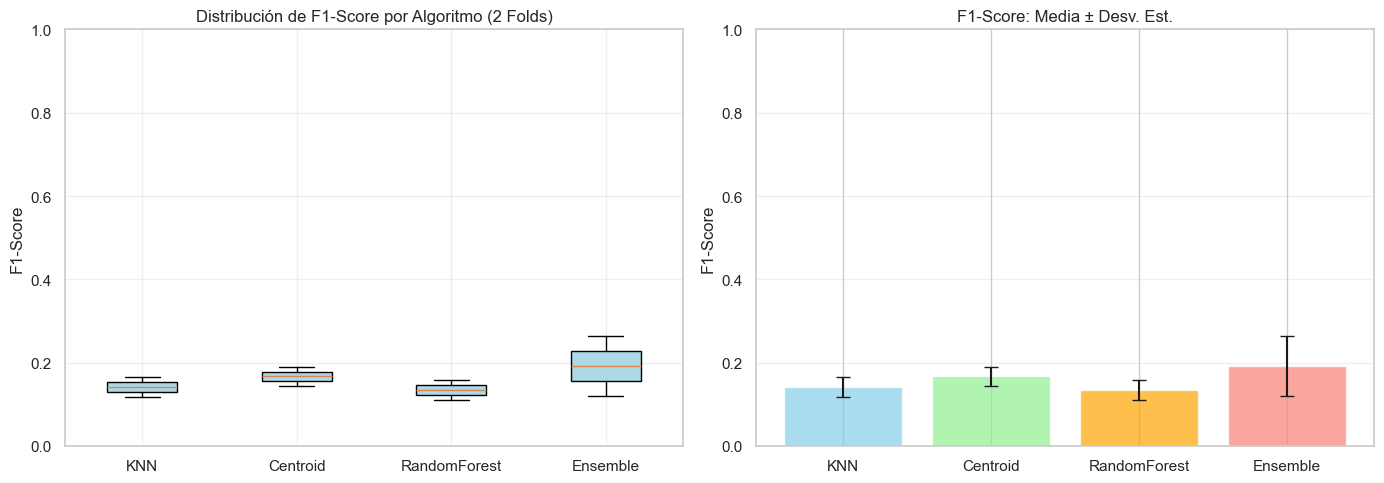


TABLA DETALLADA - F1-SCORE POR FOLD


,KNN,Centroid,RandomForest,Ensemble
Fold 1,0.1168,0.1901,0.1100,0.1205
Fold 2,0.1650,0.1434,0.1590,0.2639
Media,0.1409,0.1667,0.1345,0.1922
Desv. Est.,0.0241,0.0234,0.0245,0.0717


In [22]:
# Ejecutar Cross Validation (CV)
results_cv = {"KNN": [], "Centroid": [], "RandomForest": [], "Ensemble": []}

for fold_idx, (idx_train, idx_test) in enumerate(skf.split(X_norm, y)):
    X_train_cv, X_test_cv = X_norm[idx_train], X_norm[idx_test]
    y_train_cv, y_test_cv = y[idx_train], y[idx_test]
    
    # KNN (k=3)
    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_train_cv, y_train_cv)
    y_pred_knn = knn.predict(X_test_cv)
    f1_knn = f1_score(y_test_cv, y_pred_knn, average='macro')
    results_cv["KNN"].append(f1_knn)
    
    # Centroid Classifier
    centroid = NearestCentroid()
    centroid.fit(X_train_cv, y_train_cv)
    y_pred_cent = centroid.predict(X_test_cv)
    f1_cent = f1_score(y_test_cv, y_pred_cent, average='macro')
    results_cv["Centroid"].append(f1_cent)
    
    # Random Forest Classifier
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train_cv, y_train_cv)
    y_pred_rf = rf.predict(X_test_cv)
    f1_rf = f1_score(y_test_cv, y_pred_rf, average='macro')
    results_cv["RandomForest"].append(f1_rf)
    
    # Ensemble (Votación: KNN + Centroid + Random Forest)
    voting = VotingClassifier(
        estimators=[
            ('knn', KNeighborsClassifier(n_neighbors=3)),
            ('centroid', NearestCentroid()),
            ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
        ],
        voting='hard'
    )
    voting.fit(X_train_cv, y_train_cv)
    y_pred_ens = voting.predict(X_test_cv)
    f1_ens = f1_score(y_test_cv, y_pred_ens, average='macro')
    results_cv["Ensemble"].append(f1_ens)
    
    print(f"Fold {fold_idx+1}: KNN={f1_knn:.4f}, Centroid={f1_cent:.4f}, RandomForest={f1_rf:.4f}, Ensemble={f1_ens:.4f}")

# Reportar
print("\n" + "=" * 80)
print("RESUMEN F1-SCORE (Macro-Average)")
print("=" * 80)
print(f"{'Algoritmo':<15} {'Media':<12} {'Desv. Est.':<12}")
print("-" * 40)

for algo in ["KNN", "Centroid", "RandomForest", "Ensemble"]:
    mean_val = np.mean(results_cv[algo])
    std_val = np.std(results_cv[algo])
    print(f"{algo:<15} {mean_val:.4f}      {std_val:.4f}")

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
algos_names = list(results_cv.keys())
box_data_cv = [results_cv[a] for a in algos_names]
ax1 = axes[0]
bp = ax1.boxplot(box_data_cv, tick_labels=algos_names, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax1.set_ylabel('F1-Score')
ax1.set_title(f'Distribución de F1-Score por Algoritmo ({n_splits} Folds)')
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1])

# Bar plot
means_cv = [np.mean(results_cv[a]) for a in algos_names]
stds_cv = [np.std(results_cv[a]) for a in algos_names]
x_pos = np.arange(len(algos_names))
ax2 = axes[1]
ax2.bar(x_pos, means_cv, yerr=stds_cv, capsize=5, color=['skyblue', 'lightgreen', 'orange', 'salmon'], alpha=0.7)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(algos_names)
ax2.set_ylabel('F1-Score')
ax2.set_title('F1-Score: Media ± Desv. Est.')
ax2.set_ylim([0, 1])
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# DataFrame de resultados
df_results = pd.DataFrame(results_cv, index=[f'Fold {i+1}' for i in range(n_splits)])
df_results.loc['Media'] = df_results.mean()
df_results.loc['Desv. Est.'] = df_results.std()

print("\n" + "=" * 80)
print("TABLA DETALLADA - F1-SCORE POR FOLD")
print("=" * 80)
display(df_results.round(4))


Inicialmente, el proyecto contemplaba un análisis de marcha más completo, incluyendo métricas de simetría y descriptores cinemáticos más ricos para caracterizar la identidad de cada sujeto. Sin embargo, durante el análisis exploratorio se identificaron limitaciones importantes en el setup de adquisición, particularmente asociadas a la vista frontal de la grabación, la inestabilidad de los landmarks en la rodilla izquierda y la pérdida de información de profundidad.

La variabilidad y el comportamiento errático de algunos keypoints redujeron la confiabilidad del cálculo de ángulos articulares. Aunque fue posible estimar ROM y segmentar ciclos, se optó por priorizar descriptores más estables, como velocidad angular y características temporales por ciclo, en lugar de depender exclusivamente de métricas articulares potencialmente inestables.

Se dedicó tiempo a explorar descriptores adicionales con el objetivo de mejorar la separabilidad entre sujetos; no obstante, la calidad de los datos limitó su efectividad y no se observaron mejoras consistentes en validación cruzada. Esto sugiere que la principal limitación del sistema no radica en el modelo de clasificación, sino en la estabilidad y riqueza informativa de las señales de entrada.

En la etapa de modelado se evaluaron KNN, Nearest Centroid, Random Forest y un modelo Ensemble mediante validación cruzada estratificada por sujeto, utilizando F1-score macro como métrica principal. Todos los modelos superaron el desempeño esperado por azar (≈0.077), lo que indica la presencia de cierta información discriminativa. No obstante, los valores obtenidos (F1 ≈ 0.13–0.19) evidencian una separabilidad limitada. El modelo Ensemble presentó el mejor desempeño promedio, aunque con mayor variabilidad entre folds.

### Evaluación del conjunto de prueba

Se dedico tiempo al etiquetado del conjunto de prueba

# Validación Externa

Evaluación del modelo Ensemble entrenado con todos los datos del conjunto principal, utilizando datos de validación externa. Algunos sujetos en la validación externa pueden ser diferentes a los del entrenamiento.


In [28]:
# =========================
# Cargar datos de validación externa
# =========================
CSV_EXT_VAL = DATA_DIR / "validacion_externa" / "pose_features_roi.csv"

df_ext = pd.read_csv(CSV_EXT_VAL)

print("=" * 80)
print("VALIDACIÓN EXTERNA - CARGA DE DATOS")
print("=" * 80)
print(f"Dimensiones del dataset de validación externa: {df_ext.shape}")
print(f"Sujetos únicos: {df_ext['subject'].nunique()}")
print(f"Sujetos: {sorted(df_ext['subject'].unique())}")

# Verificar que la columna de ángulo de rodilla exista o calcularla
if "knee_angle_r" not in df_ext.columns:
    angles_r_ext = []
    for _, row in df_ext.iterrows():
        hip_r = np.array([row["hip_r_x"], row["hip_r_y"]])
        knee_r = np.array([row["knee_r_x"], row["knee_r_y"]])
        ankle_r = np.array([row["ankle_r_x"], row["ankle_r_y"]])
        
        if not np.any(np.isnan([*hip_r, *knee_r, *ankle_r])):
            v1 = hip_r - knee_r
            v2 = ankle_r - knee_r
            cosang = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
            cosang = np.clip(cosang, -1.0, 1.0)
            angle = np.degrees(np.arccos(cosang))
            angles_r_ext.append(angle)
        else:
            angles_r_ext.append(np.nan)
    
    df_ext["knee_angle_r"] = angles_r_ext

print(f"\n✓ Datos de validación externa cargados")


VALIDACIÓN EXTERNA - CARGA DE DATOS
Dimensiones del dataset de validación externa: (3536, 27)
Sujetos únicos: 4
Sujetos: ['Joan', 'Tony', 'hombre', 'mujer']

✓ Datos de validación externa cargados


In [29]:
# =========================
# Extracción de características frame-level - Validación Externa
# =========================
frame_level_features_ext = []

for (subject, trial), group in df_ext.groupby(["subject", "trial"]):
    # Obtener la señal de ángulo de rodilla derecha
    signal = group["knee_angle_r"].values
    
    # Filtrar valores válidos (no NaN)
    valid_signal = signal[~np.isnan(signal)]
    
    if len(valid_signal) < 10:  # Necesitamos al menos 10 frames válidos
        continue
    
    # Calcular características estadísticas (idénticas a model_df)
    features_dict = {
        "subject": subject,
        "trial": trial,
        
        # Estadísticas básicas
        "knee_angle_mean": np.mean(valid_signal),
        "knee_angle_std": np.std(valid_signal),
        "knee_angle_min": np.min(valid_signal),
        "knee_angle_max": np.max(valid_signal),
        "knee_angle_range": np.max(valid_signal) - np.min(valid_signal),
        "knee_angle_median": np.median(valid_signal),
        
        # Velocidad angular
        "angular_velocity_mean": np.mean(np.abs(np.gradient(valid_signal))),
        "angular_velocity_std": np.std(np.abs(np.gradient(valid_signal))),
        "angular_velocity_max": np.max(np.abs(np.gradient(valid_signal))),
        
        # Velocidad angular en °/seg
        "angular_velocity_deg_per_s_mean": np.mean(np.abs(np.gradient(valid_signal))) * FPS,
        "angular_velocity_deg_per_s_std": np.std(np.abs(np.gradient(valid_signal))) * FPS,
        "angular_velocity_deg_per_s_max": np.max(np.abs(np.gradient(valid_signal))) * FPS,
        
        # Variabilidad
        "coefficient_of_variation": (np.std(valid_signal) / np.mean(valid_signal)) * 100 if np.mean(valid_signal) > 0 else 0,
        
        # Número de frames válidos
        "n_valid_frames": len(valid_signal),
    }
    
    frame_level_features_ext.append(features_dict)

# Crear DataFrame con características a nivel de frame
model_df_ext = pd.DataFrame(frame_level_features_ext)

print("=" * 80)
print("CARACTERÍSTICAS EXTRAÍDAS - VALIDACIÓN EXTERNA")
print("=" * 80)
print(f"Total de muestras (trials): {len(model_df_ext)}")
print(f"Sujetos únicos: {model_df_ext['subject'].nunique()}")
print(f"\nDistribución por sujeto:")
print(model_df_ext['subject'].value_counts().to_string())
print(f"\nPrimeras filas:")
display(model_df_ext.head())


CARACTERÍSTICAS EXTRAÍDAS - VALIDACIÓN EXTERNA
Total de muestras (trials): 4
Sujetos únicos: 4

Distribución por sujeto:
subject
Joan      1
Tony      1
hombre    1
mujer     1

Primeras filas:


,subject,trial,knee_angle_mean,knee_angle_std,knee_angle_min,knee_angle_max,knee_angle_range,knee_angle_median,angular_velocity_mean,angular_velocity_std,angular_velocity_max,angular_velocity_deg_per_s_mean,angular_velocity_deg_per_s_std,angular_velocity_deg_per_s_max,coefficient_of_variation,n_valid_frames
0,Joan,na,169.450260,19.361522,41.316928,179.995097,138.678169,176.641546,3.293571,6.324305,60.329030,98.807126,189.729164,1809.870887,11.426080,904
1,Tony,na,157.656681,28.340704,0.665479,179.999360,179.333881,168.205612,5.834703,8.241478,78.118734,175.041105,247.244349,2343.562024,17.976215,951
2,hombre,na,164.695973,21.023305,56.430516,179.994848,123.564333,173.454292,3.587156,5.604121,53.613104,107.614680,168.123642,1608.393113,12.764918,851
3,mujer,na,166.471391,20.370852,14.509686,179.954881,165.445195,173.111071,4.148881,9.858083,145.600680,124.466424,295.742489,4368.020391,12.236849,830


In [30]:
# =========================
# Detección de ciclos y características a nivel de ciclo - Validación Externa
# =========================

# Calcular ángulos de rodilla para df_ext si no existen
if "knee_angle_r" not in df_ext.columns or df_ext["knee_angle_r"].isna().all():
    angles_r_ext = []
    for _, row in df_ext.iterrows():
        hip_r = np.array([row["hip_r_x"], row["hip_r_y"]])
        knee_r = np.array([row["knee_r_x"], row["knee_r_y"]])
        ankle_r = np.array([row["ankle_r_x"], row["ankle_r_y"]])
        
        if not np.any(np.isnan([*hip_r, *knee_r, *ankle_r])):
            v1 = hip_r - knee_r
            v2 = ankle_r - knee_r
            cosang = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
            cosang = np.clip(cosang, -1.0, 1.0)
            angle = np.degrees(np.arccos(cosang))
            angles_r_ext.append(angle)
        else:
            angles_r_ext.append(np.nan)
    
    df_ext["knee_angle_r"] = angles_r_ext

# Eliminar valores no fisiológicos e interpolar
df_ext.loc[df_ext["knee_angle_r"] < 90, "knee_angle_r"] = np.nan
df_ext["knee_angle_r"] = (
    df_ext.groupby(["subject", "trial"])["knee_angle_r"]
      .transform(lambda x: x.interpolate(limit=5))
)

# Detectar picos en validación externa
all_peaks_r_ext = []

for (subject, trial), group in df_ext.groupby(["subject", "trial"]):
    indices = group.index.values
    signal_r = group["knee_angle_r"].values
    
    if len(signal_r) > 11 and not np.any(np.isnan(signal_r)):
        signal_smooth_r = savgol_filter(signal_r, window_length=11, polyorder=2)
        
        peaks_r, _ = find_peaks(
            -signal_smooth_r,
            distance=20,
            prominence=10
        )
        
        valid_peaks_r = [p for p in peaks_r if signal_smooth_r[p] < 145]
        global_peaks_r = indices[valid_peaks_r]
        all_peaks_r_ext.extend(global_peaks_r)

peaks_r_ext = np.array(sorted(all_peaks_r_ext))

# Crear ciclos
cycles_r_ext = []
for i in range(len(peaks_r_ext) - 1):
    start_idx = peaks_r_ext[i]
    end_idx = peaks_r_ext[i + 1]
    
    if (df_ext.iloc[start_idx]["subject"] == df_ext.iloc[end_idx]["subject"] and
        df_ext.iloc[start_idx]["trial"] == df_ext.iloc[end_idx]["trial"]):
        cycles_r_ext.append((start_idx, end_idx))

print(f"Picos detectados (ext): {len(peaks_r_ext)}")
print(f"Ciclos válidos (ext): {len(cycles_r_ext)}")

# Calcular características a nivel de ciclo para validación externa
cycle_features_ext = {}

for (subject, trial), group in df_ext.groupby(["subject", "trial"]):
    idx_key = (subject, trial)
    cycle_features_ext[idx_key] = {
        "n_cycles": 0,
        "ROM_mean": np.nan,
        "ROM_std": np.nan,
        "cycle_duration_mean": np.nan,
        "cycle_duration_std": np.nan,
        "CV_duration": np.nan,
        "cycle_angular_vel_mean": np.nan,
        "cycle_angular_vel_std": np.nan,
    }
    
    subject_cycles = [c for c in cycles_r_ext 
                     if df_ext.iloc[c[0]]["subject"] == subject and 
                        df_ext.iloc[c[0]]["trial"] == trial]
    
    if len(subject_cycles) > 0:
        roms = []
        durations = []
        ang_vels = []
        
        for start_idx, end_idx in subject_cycles:
            signal = df_ext.loc[start_idx:end_idx, "knee_angle_r"].values
            
            if not np.any(np.isnan(signal)) and len(signal) > 2:
                rom = np.max(signal) - np.min(signal)
                roms.append(rom)
                
                duration = (end_idx - start_idx) / FPS
                durations.append(duration)
                
                vel = np.mean(np.abs(np.gradient(signal)))
                ang_vels.append(vel)
        
        if len(roms) > 0:
            cycle_features_ext[idx_key]["n_cycles"] = len(roms)
            cycle_features_ext[idx_key]["ROM_mean"] = np.mean(roms)
            cycle_features_ext[idx_key]["ROM_std"] = np.std(roms)
            cycle_features_ext[idx_key]["cycle_duration_mean"] = np.mean(durations)
            cycle_features_ext[idx_key]["cycle_duration_std"] = np.std(durations)
            
            if np.mean(durations) > 0:
                cycle_features_ext[idx_key]["CV_duration"] = (
                    100 * np.std(durations) / np.mean(durations)
                )
            
            cycle_features_ext[idx_key]["cycle_angular_vel_mean"] = np.mean(ang_vels)
            cycle_features_ext[idx_key]["cycle_angular_vel_std"] = np.std(ang_vels)

# Agregar características de ciclo a model_df_ext
for idx, row in model_df_ext.iterrows():
    key = (row["subject"], row["trial"])
    if key in cycle_features_ext:
        for col, val in cycle_features_ext[key].items():
            model_df_ext.at[idx, col] = val

print(f"\n✓ Características a nivel de ciclo agregadas a validación externa")
print(f"Muestra de características:")
display(model_df_ext[["subject", "trial", "n_cycles", "ROM_mean", "cycle_duration_mean", "CV_duration"]].head())


Picos detectados (ext): 25
Ciclos válidos (ext): 22

✓ Características a nivel de ciclo agregadas a validación externa
Muestra de características:


,subject,trial,n_cycles,ROM_mean,cycle_duration_mean,CV_duration
0,Joan,na,6.0,87.151450,3.650000,76.036653
1,Tony,na,0.0,NaN,NaN,NaN
2,hombre,na,11.0,71.709433,1.969697,80.209784
3,mujer,na,5.0,75.801934,3.966667,82.775455


EVALUACIÓN CON ENSEMBLE - VALIDACIÓN EXTERNA
Datos de entrenamiento: 48 muestras, 13 sujetos
Datos de validación externa: 4 muestras, 4 sujetos

✓ Ensemble entrenado con todos los datos de entrenamiento
✓ F1-Score (validación externa): 0.0000

MATRIZ DE CONFUSIÓN - VALIDACIÓN EXTERNA

Sujetos reales: ['Joan', 'Tony', 'hombre', 'mujer']
Sujetos predichos: ['Edgar', 'Norman']
Todas las etiquetas en matriz: ['Edgar', 'Joan', 'Norman', 'Tony', 'hombre', 'mujer']

Matriz de confusión:


,Pred: Edgar,Pred: Joan,Pred: Norman,Pred: Tony,Pred: hombre,Pred: mujer
Real: Edgar,0,0,0,0,0,0
Real: Joan,0,0,1,0,0,0
Real: Norman,0,0,0,0,0,0
Real: Tony,1,0,0,0,0,0
Real: hombre,0,0,1,0,0,0
Real: mujer,1,0,0,0,0,0


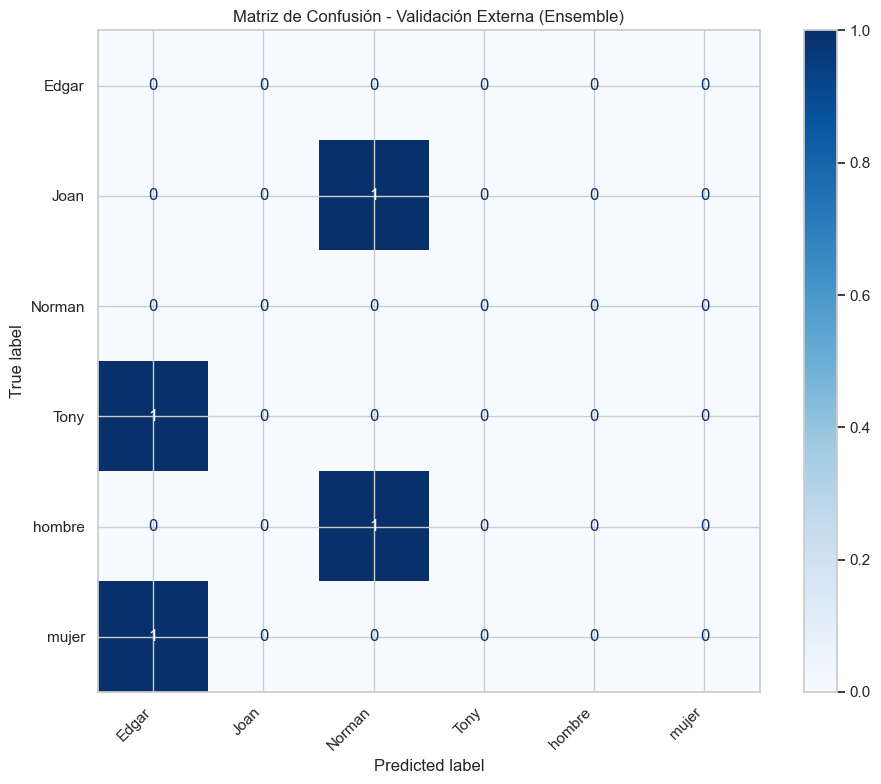


REPORTE DE CLASIFICACIÓN - VALIDACIÓN EXTERNA
              precision    recall  f1-score   support

       Edgar       0.00      0.00      0.00       0.0
        Joan       0.00      0.00      0.00       1.0
      Norman       0.00      0.00      0.00       0.0
        Tony       0.00      0.00      0.00       1.0
      hombre       0.00      0.00      0.00       1.0
       mujer       0.00      0.00      0.00       1.0

    accuracy                           0.00       4.0
   macro avg       0.00      0.00      0.00       4.0
weighted avg       0.00      0.00      0.00       4.0



In [31]:
# =========================
# Validación Externa - Ensemble Classifier
# =========================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Extraer características de validación externa (mismo esquema que entrenamiento)
X_ext = model_df_ext[feature_cols].values
y_ext = model_df_ext["subject"].values

# Normalizar usando parámetros de entrenamiento (X_mean y X_std)
X_ext_norm = (X_ext - X_mean) / X_std

print("=" * 80)
print("EVALUACIÓN CON ENSEMBLE - VALIDACIÓN EXTERNA")
print("=" * 80)
print(f"Datos de entrenamiento: {len(X_norm)} muestras, {len(np.unique(y))} sujetos")
print(f"Datos de validación externa: {len(X_ext_norm)} muestras, {len(np.unique(y_ext))} sujetos")
print()

# Entrenar Ensemble con TODOS los datos de entrenamiento
ensemble_final = VotingClassifier(
    estimators=[
        ('knn', KNeighborsClassifier(n_neighbors=3)),
        ('centroid', NearestCentroid()),
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
    ],
    voting='hard'
)

ensemble_final.fit(X_norm, y)
print("✓ Ensemble entrenado con todos los datos de entrenamiento")

# Predicciones en validación externa
y_pred_ext = ensemble_final.predict(X_ext_norm)

# Calcular F1-Score
f1_ext = f1_score(y_ext, y_pred_ext, average='macro')
print(f"✓ F1-Score (validación externa): {f1_ext:.4f}")

# Obtener etiquetas únicas de ambos conjuntos (reales y predichos)
labels_ext = sorted(np.unique(np.concatenate([y_ext, y_pred_ext])))

# Matriz de confusión usando solo las clases presentes en validación externa
cm = confusion_matrix(y_ext, y_pred_ext, labels=labels_ext)

print("\n" + "=" * 80)
print("MATRIZ DE CONFUSIÓN - VALIDACIÓN EXTERNA")
print("=" * 80)
print(f"\nSujetos reales: {sorted(np.unique(y_ext))}")
print(f"Sujetos predichos: {sorted(np.unique(y_pred_ext))}")
print(f"Todas las etiquetas en matriz: {labels_ext}")
print("\nMatriz de confusión:")
cm_df = pd.DataFrame(
    cm,
    index=[f"Real: {s}" for s in labels_ext],
    columns=[f"Pred: {s}" for s in labels_ext]
)
display(cm_df)

# Visualizar matriz de confusión
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels_ext
)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Matriz de Confusión - Validación Externa (Ensemble)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Reporte detallado
from sklearn.metrics import classification_report

print("\n" + "=" * 80)
print("REPORTE DE CLASIFICACIÓN - VALIDACIÓN EXTERNA")
print("=" * 80)
print(classification_report(y_ext, y_pred_ext, labels=labels_ext))


## Discusión y conclusiones

El objetivo del proyecto fue evaluar si era posible identificar individuos a partir de descriptores cinemáticos derivados del análisis de marcha. Aunque inicialmente se planteó un enfoque más completo, las limitaciones del setup de adquisición —particularmente la vista frontal, la inestabilidad de algunos landmarks y la pérdida de información de profundidad— redujeron la calidad y estabilidad de las señales disponibles.

A pesar de estas limitaciones, se lograron extraer descriptores como ROM, duración del ciclo, cadencia y velocidad angular. En validación cruzada, los modelos superaron el desempeño esperado por azar, lo que indica que existe cierta información discriminativa en los datos. Sin embargo, en la evaluación externa el desempeño fue muy bajo, lo que evidencia una capacidad limitada de generalización.

Esto sugiere que las características utilizadas no son suficientes para construir una firma biométrica robusta bajo las condiciones actuales. Aunque no todos los sujetos del conjunto de prueba eran completamente nuevos, el modelo no logró diferenciarlos de manera consistente, lo que confirma la baja separabilidad entre clases.

Se consideró la posibilidad de incluir otros landmarks y características dinámicas adicionales, como patrones de balanceo u otras señales corporales, que podrían aportar mayor información discriminativa. No obstante, para mantener el enfoque en la marcha y debido a limitaciones de tiempo, estas alternativas no fueron exploradas.

En conclusión, los resultados muestran que la principal limitación del sistema no fue el modelo de clasificación, sino la calidad de los datos y la riqueza de los descriptores disponibles. Este trabajo resalta la importancia crítica de la adquisición y selección de características en tareas de identificación basadas en análisis de movimiento.